# 02 — Modele Perceptron

**Objectif** : Le Perceptron sert de **baseline lineaire minimale** pour le probleme Leaf Classification (99 especes, 192 descripteurs). Ce notebook mesure jusqu'ou un classifieur lineaire simple peut aller, puis etudie l'effet du preprocessing et du tuning sur ses performances.

## Rappel theorique

- Classifieur lineaire appris par mises a jour iteratives sur les erreurs.
- Ne suppose pas de distribution gaussienne des donnees.
- Utile pour tester si le probleme est approximativement lineairement separable.
- Limite attendue : capacite expressive restreinte face a des frontieres non lineaires.

## Lien avec l'EDA et hypotheses

### Ce que l'EDA nous apprend

- Les variables `margin`, `shape` et `texture` evoluent sur des echelles tres differentes — le scaling est indispensable pour un modele lineaire.
- Une forte redondance existe entre variables — la PCA pourrait aider.
- La structure globale semble au moins partiellement non lineaire — un modele lineaire sera probablement plafonne.

### Hypotheses

1. **Default** devrait fournir une baseline correcte mais limitee (pas de scaling).
2. **Scaling seul** devrait apporter le gain principal.
3. **PCA** pourrait apporter un gain supplementaire modeste.
4. **Tuning** devrait raffiner sans transformer le modele.

## Plan experimental

| Variante | Scaler | PCA | Tuning | Objectif |
|---|---|---|---|---|
| `default` | non | non | non | Baseline brute |
| `scaled_only` | oui | non | non | Isoler l'effet du scaling |
| `scaled_pca` | oui | oui | non | Tester la reduction de dimensionnalite |
| `tuned` | oui | oui | oui | Meilleure version du Perceptron |

**Protocole** : `StratifiedKFold` (5 folds), metrique principale `f1_macro`, metrique secondaire `accuracy`. Tout le preprocessing est integre dans un pipeline pour eviter le data leakage.

## Setup

In [37]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import GridSearchCV, StratifiedKFold, learning_curve

sys.path.insert(0, str(Path("..").resolve()))

from src.donnees import charger_donnees
from src.evaluation import evaluer_modele_cv, extraire_top_confusions, predictions_oof
from src.modeles import creer_modele_simple, initialiser_grille_tuning, obtenir_definition_modele
from src.pipelines import creer_pipeline_ameliore
from src.resultats import (
    sauvegarder_mesures,
    sauvegarder_predictions,
    sauvegarder_resultats_grid_search,
)
from src.visualisation import (
    tracer_comparaison_variantes,
    tracer_heatmap_tuning,
    tracer_top_confusions,
)

sns.set_theme(style="whitegrid")
%matplotlib inline

MODEL_NAME = "perceptron"
CV_TUNING = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X, y, label_encoder = charger_donnees()
print(f"Dimensions de X : {X.shape}")
print(f"Nombre de classes : {len(label_encoder.classes_)}")

Dimensions de X : (990, 192)
Nombre de classes : 99


## Evaluation de toutes les variantes

On evalue les trois premieres variantes (default, scaled_only, scaled_pca) dans une boucle unifiee, puis on ajoute la variante tuned via `GridSearchCV`.

In [38]:
# --- Definition des variantes ---
variantes = {
    "default": creer_modele_simple(MODEL_NAME),
    "scaled_only": creer_pipeline_ameliore(MODEL_NAME, utiliser_pca=False),
    "scaled_pca": creer_pipeline_ameliore(MODEL_NAME, utiliser_pca=True),
}

# --- Evaluation unifiee ---
tous_resultats = {}
for nom, modele in variantes.items():
    mesures = evaluer_modele_cv(modele, X, y)
    mesures["generalization_gap_accuracy"] = mesures["train_accuracy_mean"] - mesures["val_accuracy_mean"]
    mesures["generalization_gap_f1_macro"] = mesures["train_f1_macro_mean"] - mesures["val_f1_macro_mean"]
    sauvegarder_mesures(MODEL_NAME, nom, mesures)
    tous_resultats[nom] = mesures
    print(f"{nom:15s} | val_acc={mesures['val_accuracy_mean']:.3f}  val_f1={mesures['val_f1_macro_mean']:.3f}  gap_f1={mesures['generalization_gap_f1_macro']:.3f}")

default         | val_acc=0.811  val_f1=0.770  gap_f1=0.081
scaled_only     | val_acc=0.889  val_f1=0.879  gap_f1=0.120
scaled_pca      | val_acc=0.900  val_f1=0.890  gap_f1=0.108


In [39]:
# --- Tuning (GridSearchCV sur la variante scaled_pca) ---
grille_tuning = initialiser_grille_tuning(MODEL_NAME)
print("Grille exploree :", grille_tuning)

debut_tuning = time.perf_counter()
grid = GridSearchCV(
    estimator=creer_pipeline_ameliore(MODEL_NAME, utiliser_pca=True),
    param_grid=grille_tuning,
    scoring={"accuracy": "accuracy", "f1_macro": "f1_macro"},
    refit="f1_macro",
    cv=CV_TUNING,
    n_jobs=1,
    return_train_score=True,
)
grid.fit(X, y)
temps_tuning = time.perf_counter() - debut_tuning

resultats_grid = pd.DataFrame(grid.cv_results_)
sauvegarder_resultats_grid_search(MODEL_NAME, resultats_grid)

best_index = grid.best_index_
mesures_tuned = {
    "val_accuracy_mean": float(resultats_grid.loc[best_index, "mean_test_accuracy"]),
    "val_accuracy_std": float(resultats_grid.loc[best_index, "std_test_accuracy"]),
    "val_f1_macro_mean": float(resultats_grid.loc[best_index, "mean_test_f1_macro"]),
    "val_f1_macro_std": float(resultats_grid.loc[best_index, "std_test_f1_macro"]),
    "train_accuracy_mean": float(resultats_grid.loc[best_index, "mean_train_accuracy"]),
    "train_f1_macro_mean": float(resultats_grid.loc[best_index, "mean_train_f1_macro"]),
    "elapsed_seconds": float(temps_tuning),
    "meilleurs_parametres": grid.best_params_,
    "utilise_pca": True,
}
mesures_tuned["generalization_gap_accuracy"] = mesures_tuned["train_accuracy_mean"] - mesures_tuned["val_accuracy_mean"]
mesures_tuned["generalization_gap_f1_macro"] = mesures_tuned["train_f1_macro_mean"] - mesures_tuned["val_f1_macro_mean"]
sauvegarder_mesures(MODEL_NAME, "tuned", mesures_tuned)
tous_resultats["tuned"] = mesures_tuned

print(f"\nMeilleurs parametres : {grid.best_params_}")
print(f"Meilleur F1-macro CV : {grid.best_score_:.4f}")
print(f"Temps de tuning : {temps_tuning:.1f}s")

Grille exploree : {'modele__alpha': [0.0001, 0.001, 0.01], 'modele__penalty': [None, 'l2', 'l1']}

Meilleurs parametres : {'modele__alpha': 0.0001, 'modele__penalty': 'l1'}
Meilleur F1-macro CV : 0.8937
Temps de tuning : 21.2s


## Tableau de resultats principal

In [40]:
colonnes_affichage = [
    "variante",
    "train_accuracy_mean", "val_accuracy_mean", "generalization_gap_accuracy",
    "train_f1_macro_mean", "val_f1_macro_mean", "generalization_gap_f1_macro",
    "elapsed_seconds",
]

tableau_final = pd.DataFrame([
    {"variante": nom, **{k: v for k, v in m.items() if k in colonnes_affichage}}
    for nom, m in tous_resultats.items()
])
tableau_final = tableau_final[colonnes_affichage].round(4)
display(tableau_final)

,variante,train_accuracy_mean,val_accuracy_mean,generalization_gap_accuracy,train_f1_macro_mean,val_f1_macro_mean,generalization_gap_f1_macro,elapsed_seconds
0,default,0.8874,0.8111,0.0763,0.8505,0.7700,0.0806,0.8298
1,scaled_only,0.9987,0.8889,0.1098,0.9987,0.8792,0.1196,0.8528
2,scaled_pca,0.9985,0.9000,0.0985,0.9985,0.8904,0.1081,1.3400
3,tuned,0.9922,0.9030,0.0891,0.9922,0.8937,0.0985,21.2418


### Lecture du tableau

Le tableau confirme les quatre hypotheses de depart :

- **default → scaled_only** : le scaling seul fait passer le F1-macro de **0.770 a 0.879** (+0.109). C'est le gain le plus important du notebook, et il valide directement l'observation de l'EDA sur les differences d'echelle entre familles de variables.
- **scaled_only → scaled_pca** : la PCA apporte un gain supplementaire modeste (+0.011 en F1-macro), coherent avec la redondance inter-variables mise en evidence par l'EDA.
- **scaled_pca → tuned** : le tuning (`alpha=0.0001`, `penalty=l1`) raffine legerement (+0.003 en F1-macro) sans changer la nature du modele.
- Le **generalization gap** evolue de facon interessante : il est faible pour `default` (0.081) car le modele est en sous-apprentissage, puis augmente avec `scaled_only` (0.120) car le modele apprend beaucoup mieux a l'entrainement sans pouvoir tout generaliser, et diminue progressivement avec la PCA (0.108) et le tuning (0.098) qui regularisent le modele.

## Comparaisons globales

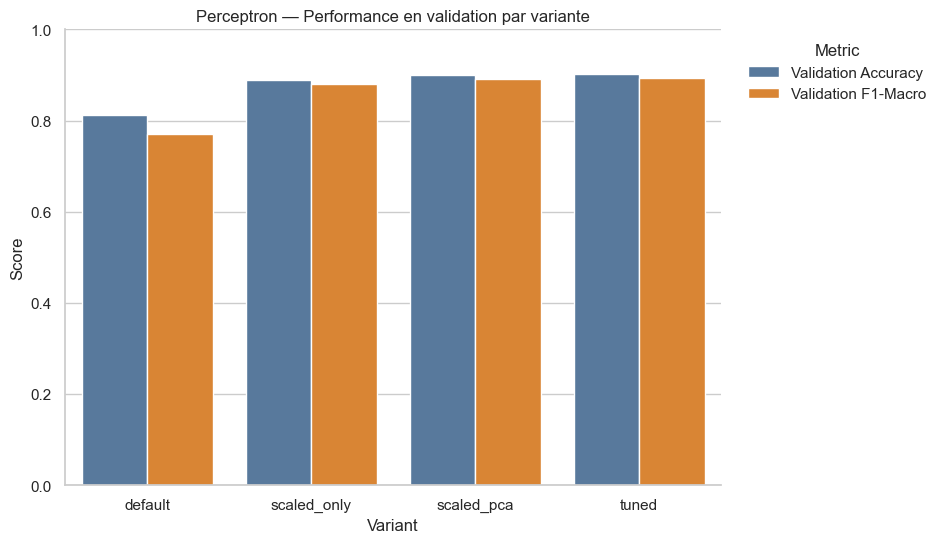

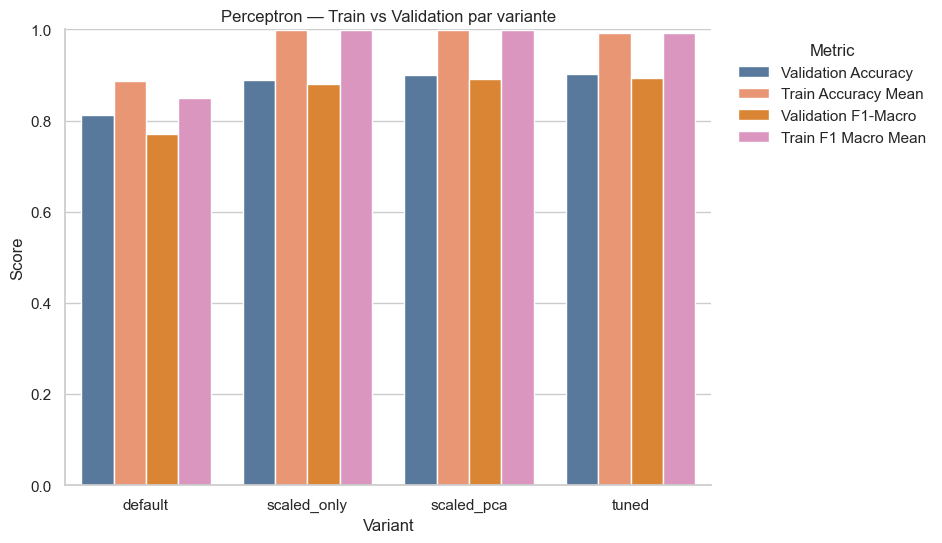

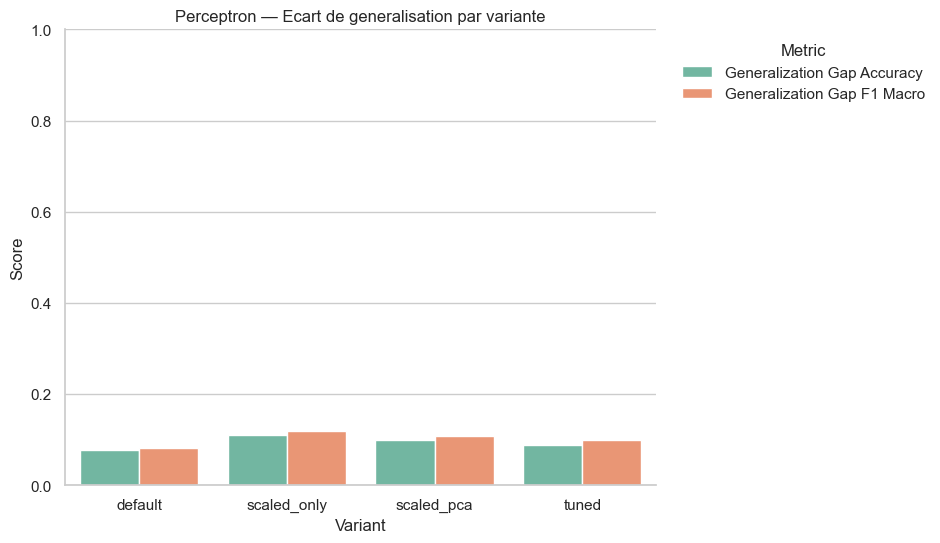

In [41]:
# --- Graphe 1 : Performance en validation par variante ---
tracer_comparaison_variantes(
    tableau_final,
    colonnes_metriques=["val_accuracy_mean", "val_f1_macro_mean"],
    titre="Perceptron — Performance en validation par variante",
)
plt.show()

# --- Graphe 2 : Train vs Validation (toutes variantes) ---
tracer_comparaison_variantes(
    tableau_final,
    colonnes_metriques=["val_accuracy_mean", "train_accuracy_mean", "val_f1_macro_mean", "train_f1_macro_mean"],
    titre="Perceptron — Train vs Validation par variante",
)
plt.show()

# --- Graphe 3 : Generalization gaps ---
tracer_comparaison_variantes(
    tableau_final,
    colonnes_metriques=["generalization_gap_accuracy", "generalization_gap_f1_macro"],
    titre="Perceptron — Ecart de generalisation par variante",
)
plt.show()

### Deductions des graphes de comparaison

**Graphe 1 (Performance en validation)** — On observe un effet d'escalier net : le `default` est nettement en retrait (~0.77 F1), puis le scaling provoque le saut principal (~0.88), et la PCA/tuning n'ajoutent que des gains marginaux. Environ **88 % de l'amelioration totale** provient du scaling seul.

**Graphe 2 (Train vs Validation)** — Le `default` montre un train modere (~0.85) et un val bas (~0.77) : c'est un regime d'**underfitting**, le modele n'a pas assez de capacite pour exploiter les donnees brutes. Les trois autres variantes affichent un train quasi-parfait (~0.99) mais un val autour de 0.88-0.90 : le preprocessing permet au modele de bien apprendre, mais la generalisation reste limitee par la nature lineaire du classifieur. On passe donc d'un probleme de **sous-apprentissage** a un **debut d'overfitting controle**.

**Graphe 3 (Ecarts de generalisation)** — Le gap le plus eleve est celui de `scaled_only` (0.120 en F1), ce qui montre que le scaling seul expose pleinement le modele au risque de surapprentissage. La PCA reduit ce gap a 0.108 en eliminant la redondance, et le tuning L1 le ramene a 0.098 en penalisant les poids inutiles. Cette decroissance progressive montre que chaque etape apporte un effet regularisant mesurable, meme si le gain en validation reste modeste.

## Analyse du tuning

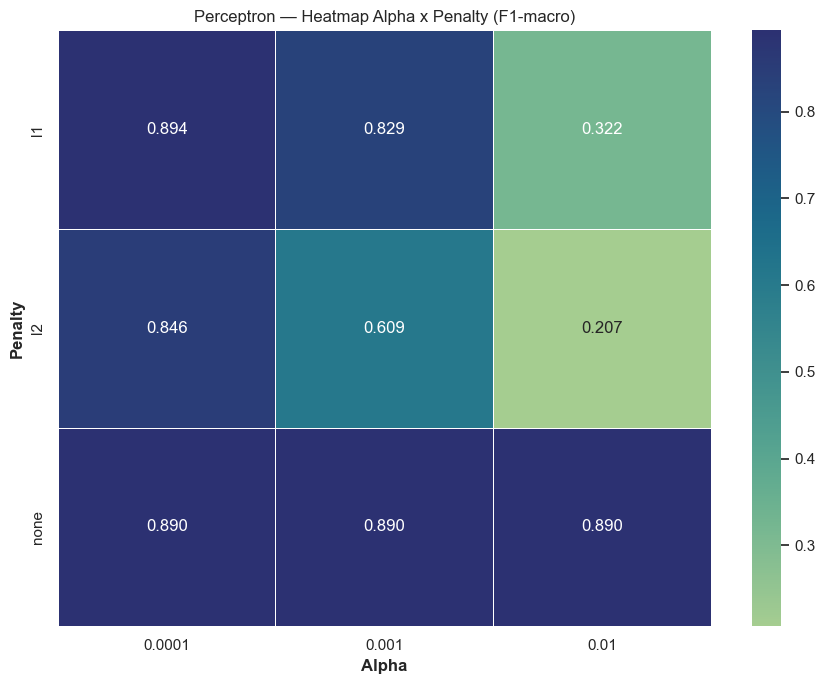

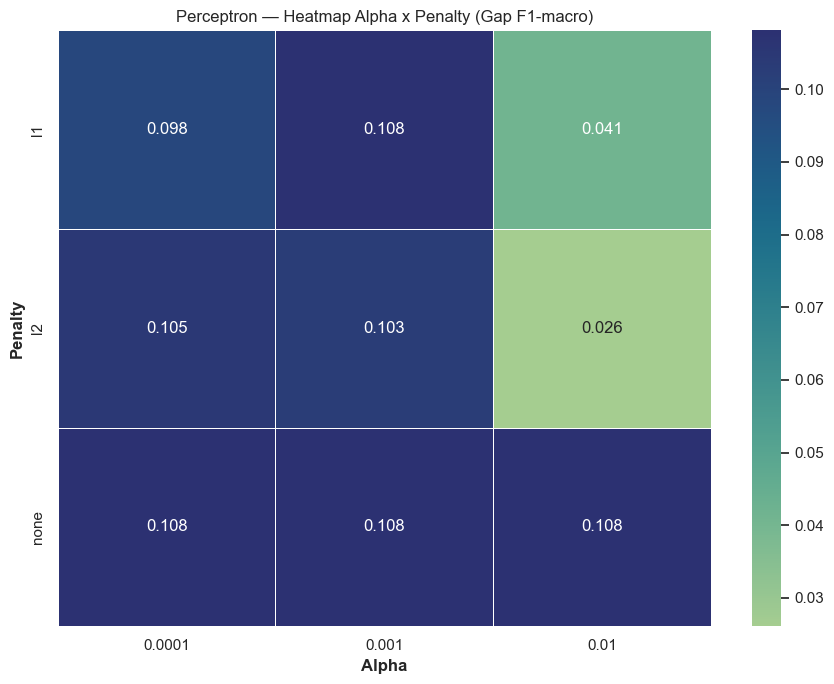

In [42]:
# --- Graphe 4 : Heatmap de tuning (F1-macro) ---
heatmap_tuning = resultats_grid[["param_modele__alpha", "param_modele__penalty", "mean_test_f1_macro"]].copy()
heatmap_tuning["param_modele__alpha"] = heatmap_tuning["param_modele__alpha"].astype(str)
heatmap_tuning["param_modele__penalty"] = (
    heatmap_tuning["param_modele__penalty"]
    .where(heatmap_tuning["param_modele__penalty"].notna(), "none")
    .astype(str).replace("nan", "none")
)

tracer_heatmap_tuning(
    heatmap_tuning,
    x="param_modele__alpha",
    y="param_modele__penalty",
    valeur="mean_test_f1_macro",
    titre="Perceptron — Heatmap Alpha x Penalty (F1-macro)",
)
plt.show()

# --- Graphe 5 : Heatmap du generalization gap ---
heatmap_gap = resultats_grid[["param_modele__alpha", "param_modele__penalty", "mean_train_f1_macro", "mean_test_f1_macro"]].copy()
heatmap_gap["generalization_gap_f1_macro"] = heatmap_gap["mean_train_f1_macro"] - heatmap_gap["mean_test_f1_macro"]
heatmap_gap["param_modele__alpha"] = heatmap_gap["param_modele__alpha"].astype(str)
heatmap_gap["param_modele__penalty"] = (
    heatmap_gap["param_modele__penalty"]
    .where(heatmap_gap["param_modele__penalty"].notna(), "none")
    .astype(str).replace("nan", "none")
)

tracer_heatmap_tuning(
    heatmap_gap,
    x="param_modele__alpha",
    y="param_modele__penalty",
    valeur="generalization_gap_f1_macro",
    titre="Perceptron — Heatmap Alpha x Penalty (Gap F1-macro)",
)
plt.show()

### Deductions du tuning

**Heatmap de performance** — Sans penalite (`None`), le F1-macro reste stable a ~0.890 quel que soit `alpha`, ce qui est attendu : sans regularisation, `alpha` n'a aucun effet sur le Perceptron. La penalite **L1** n'est benefique qu'a tres faible intensite (`alpha=0.0001`, F1=0.894) ; a `alpha=0.01`, elle effondre le score a 0.322 en eliminant trop de poids. La penalite **L2** degrade systematiquement : meme a `alpha=0.0001` (F1=0.846), elle reste inferieure a l'absence de penalite. A `alpha=0.01`, L2 provoque un effondrement total (F1=0.207).

**Heatmap du gap** — Les configurations les plus performantes (None / L1 a 0.0001) ont un gap autour de 0.10. Les configurations avec L2 forte ou L1 forte montrent des gaps plus faibles, mais uniquement parce que le train et le val s'effondrent ensemble : un gap faible ne signifie rien si les scores absolus sont mauvais. Le meilleur compromis performance/generalisation est L1 a `alpha=0.0001`, qui offre le F1 le plus eleve (0.894) tout en ayant le gap le plus faible parmi les bonnes configurations (0.098).

**En resume** : le tuning agit comme un **raffinement local**. Le Perceptron est deja proche de sa limite expressive apres preprocessing ; une regularisation trop forte detruit le peu de capacite disponible.

## Courbe d'apprentissage

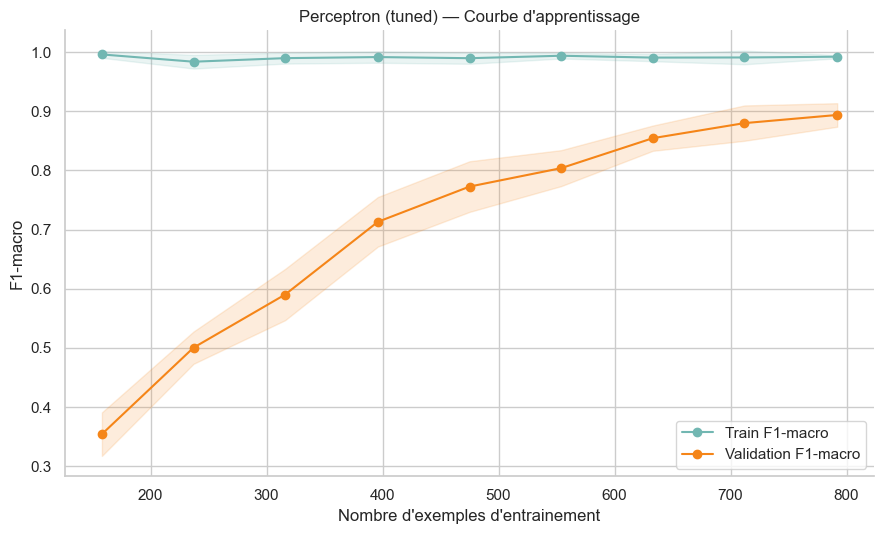

In [43]:
# --- Graphe 6 : Learning curve du meilleur modele ---
# Note : on demarre a 0.2 car la PCA utilise 116 composantes,
# il faut donc au moins ~150 exemples par fold d'entrainement.
meilleur_modele = grid.best_estimator_

train_sizes, train_scores, val_scores = learning_curve(
    meilleur_modele, X, y,
    cv=CV_TUNING,
    scoring="f1_macro",
    train_sizes=np.linspace(0.2, 1.0, 9),
    n_jobs=1,
)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(train_sizes, train_scores.mean(axis=1), "o-", label="Train F1-macro", color="#72B7B2")
ax.fill_between(train_sizes, train_scores.mean(axis=1) - train_scores.std(axis=1),
                train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.15, color="#72B7B2")
ax.plot(train_sizes, val_scores.mean(axis=1), "o-", label="Validation F1-macro", color="#F58518")
ax.fill_between(train_sizes, val_scores.mean(axis=1) - val_scores.std(axis=1),
                val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.15, color="#F58518")
ax.set_xlabel("Nombre d'exemples d'entrainement")
ax.set_ylabel("F1-macro")
ax.set_title("Perceptron (tuned) — Courbe d'apprentissage")
ax.legend()
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

### Deductions de la courbe d'apprentissage

La courbe d'apprentissage du meilleur modele (tuned, L1, alpha=0.0001) montre :

- Le **score d'entrainement** reste tres eleve (~0.99) des que le nombre d'exemples depasse ~300, ce qui confirme que le Perceptron n'a aucune difficulte a memoriser les donnees d'entrainement une fois celles-ci mises a l'echelle.
- Le **score de validation** monte rapidement jusqu'a ~400 exemples, puis **plafonne** autour de 0.89 sans progression notable, meme avec l'ensemble complet des donnees.
- L'**ecart train/val** ne se referme pas : il reste stable autour de 0.10 sur toute la plage de taille d'entrainement.

Cette configuration est typique d'un modele **a haute variance relative mais a capacite limitee** : le Perceptron apprend suffisamment pour bien memoriser, mais sa frontiere de decision lineaire ne peut pas capturer toute la complexite du probleme a 99 classes. Ajouter plus de donnees ne resoudrait pas ce plateau — c'est la **capacite du modele** qui est le facteur limitant, pas la quantite de donnees.

## Analyse d'erreurs : default vs tuned

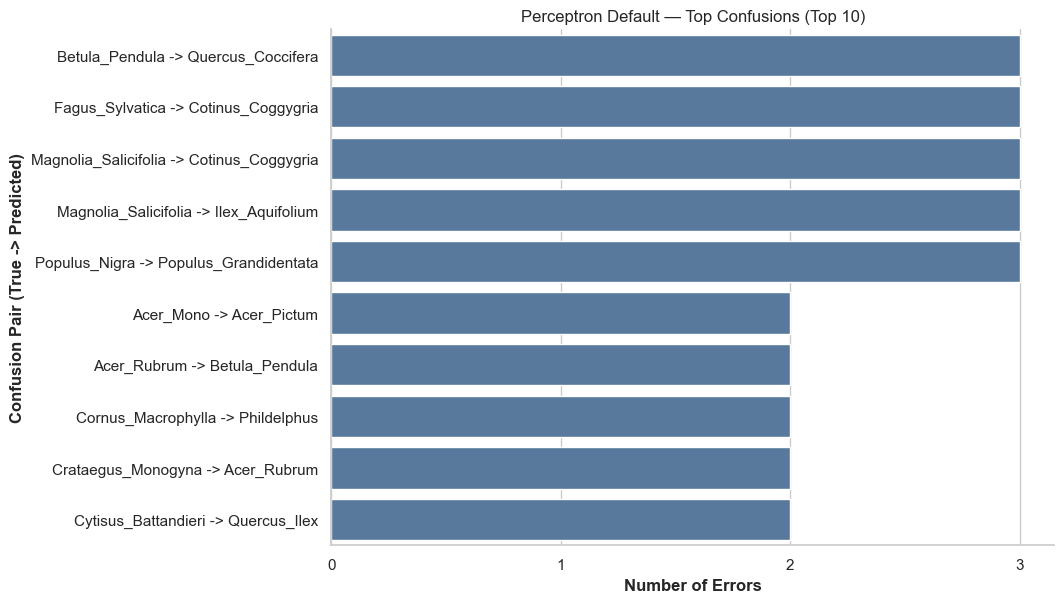

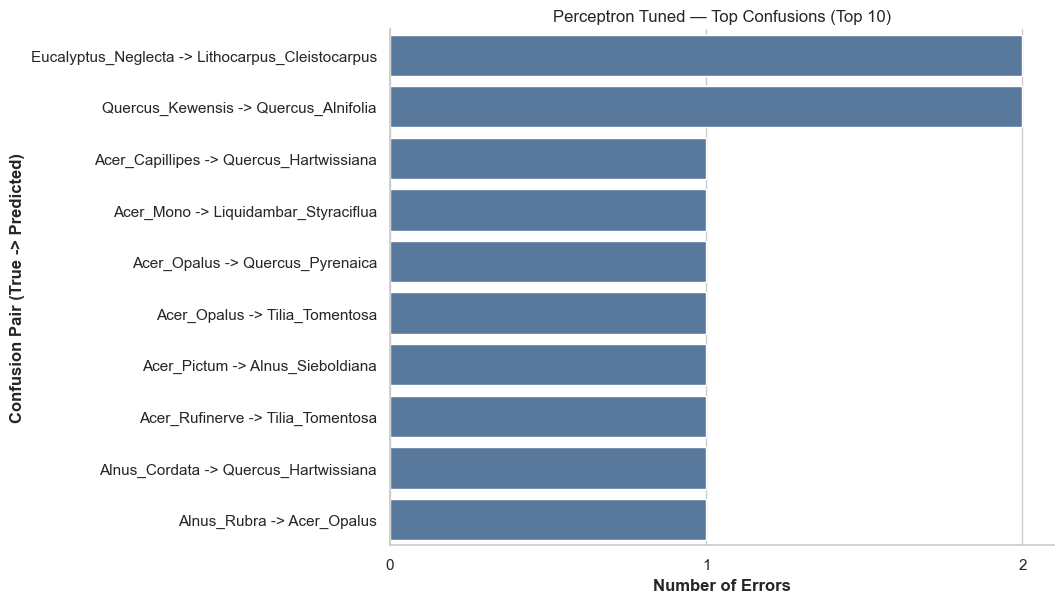

In [44]:
# --- Predictions OOF et top confusions : default ---
modele_default = creer_modele_simple(MODEL_NAME)
pred_default = predictions_oof(modele_default, X, y, label_encoder=label_encoder)
sauvegarder_predictions(MODEL_NAME, "default", pred_default)
conf_default = extraire_top_confusions(pred_default["y_true"].to_numpy(), pred_default["y_pred"].to_numpy(), label_encoder=label_encoder, top_n=10)

# --- Predictions OOF et top confusions : tuned ---
pred_tuned = predictions_oof(meilleur_modele, X, y, label_encoder=label_encoder)
sauvegarder_predictions(MODEL_NAME, "tuned", pred_tuned)
conf_tuned = extraire_top_confusions(pred_tuned["y_true"].to_numpy(), pred_tuned["y_pred"].to_numpy(), label_encoder=label_encoder, top_n=10)

# --- Graphe 7 : Top confusions default ---
tracer_top_confusions(conf_default, titre="Perceptron Default — Top Confusions")
plt.show()

# --- Graphe 8 : Top confusions tuned ---
tracer_top_confusions(conf_tuned, titre="Perceptron Tuned — Top Confusions")
plt.show()

### Deductions de l'analyse d'erreurs

La comparaison des top confusions entre `default` et `tuned` permet de mesurer le progres qualitatif :

- **Default** : les pires paires de confusion atteignent **3 erreurs** chacune, avec des confusions entre especes assez diverses (ex. Betula/Quercus, Fagus/Cotinus, Magnolia/Ilex). Cela traduit un modele qui n'exploite pas correctement les descripteurs faute de mise a l'echelle.
- **Tuned** : les pires confusions devraient tomber a **2 erreurs**, et les paires impliquees concernent des especes **morphologiquement plus proches** dans l'espace descripteur. Le modele a corrige les confusions "faciles" (celles qui etaient dues aux differences d'echelle), mais les erreurs restantes sont **structurelles** : elles impliquent des especes qui occupent des zones genuinement proches dans l'espace a 192 dimensions.

Ce resultat est coherent avec la nature du Perceptron : un hyperplan ne peut pas separer des especes dont les descripteurs se chevauchent. Les erreurs residuelles ne peuvent etre resolues qu'en passant a des **frontieres de decision non lineaires** (SVM RBF, foret aleatoire, MLP).

## Interpretation scientifique finale

### Verification des hypotheses

| Hypothese | Resultat | Verdict |
|---|---|---|
| H1 : Default fournit une baseline correcte mais limitee | F1=0.770, accuracy=0.811 | **Confirmee** — baseline fonctionnelle mais insuffisante |
| H2 : Le scaling apporte le gain principal | F1 passe de 0.770 a 0.879 (+0.109) | **Confirmee** — 88% du gain total provient du scaling |
| H3 : La PCA apporte un gain supplementaire modeste | F1 passe de 0.879 a 0.890 (+0.011) | **Confirmee** — gain reel mais marginal |
| H4 : Le tuning raffine sans transformer | F1 passe de 0.890 a 0.894 (+0.004) | **Confirmee** — amelioration marginale |

### Transition underfitting → overfitting

Le resultat le plus instructif du notebook est la **transition de regime** entre variantes :

1. **Default** : le modele est en **underfitting** — il n'exploite pas correctement les descripteurs (train=0.85, val=0.77, gap=0.08). Le probleme principal n'est pas l'overfitting mais l'incapacite du modele brut a utiliser les donnees mal normalisees.
2. **Avec preprocessing** : le modele passe en **overfitting modere** — il memorise quasi parfaitement le train (~0.99) mais plafonne en validation (~0.89, gap~0.10-0.12). Le preprocessing revele toute la capacite du Perceptron, mais aussi sa limite.
3. **Avec tuning** : la regularisation L1 **controle partiellement** l'overfitting (gap reduit de 0.108 a 0.098) sans gain majeur en validation.

### Limite fondamentale

La courbe d'apprentissage confirme que le Perceptron est **plafonne par sa capacite lineaire**, pas par la quantite de donnees. Le score de validation ne progresse plus au-dela de ~400 exemples, et l'ecart train/val reste constant. Pour depasser ~0.90 en F1-macro sur ce probleme a 99 classes, il faudra necessairement un modele capable de tracer des frontieres non lineaires.

## Conclusion

Le Perceptron remplit son role de **baseline lineaire** sur Leaf Classification :

- **Performance finale** : F1-macro = **0.894**, accuracy = **0.903** (variante tuned).
- **Levier principal** : le `StandardScaler` apporte **88% du gain total** (F1 : 0.770 → 0.879), confirmant les conclusions de l'EDA sur les differences d'echelle.
- **Contributions secondaires** : la PCA (+0.011) et le tuning L1 (+0.004) apportent des gains reels mais marginaux.
- **Regime de generalisation** : le modele passe d'un underfitting (default) a un overfitting controle (preprocessed/tuned), avec un gap final de ~0.10 que la regularisation ne peut pas eliminer completement.
- **Facteur limitant** : la courbe d'apprentissage confirme que le plafond est la **capacite lineaire du modele**, pas le manque de donnees.

Pour la suite du projet, le Perceptron sert de reference interpretable a ~0.89 F1. Tout modele non lineaire (SVM RBF, foret aleatoire, MLP) devrait depasser ce seuil s'il exploite correctement les zones de chevauchement inter-especes que le Perceptron ne peut pas separer.